# Лабораторная работа №3

#### Вариант 4
#### Задание 1. Считать данные из файла и вывести метод первые 20 его строк (метод head()).

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv('.//Mall_Customers_1.csv')

display(data.head(20))

,CustomerID,Genre,Age,AnnualIncome,Spending Score (1-100)
0,1,Male,NaN,15.0,39.0
1,2,Male,21.0,NaN,81.0
2,3,Female,NaN,16.0,6.0
3,4,Female,23.0,16.0,77.0
4,5,Female,31.0,17.0,40.0
5,6,Female,22.0,17.0,76.0
6,7,Female,NaN,18.0,6.0
7,8,Female,23.0,NaN,94.0
8,9,Male,64.0,19.0,NaN
9,10,Female,30.0,19.0,72.0


#### Задание 2. Проверить наличие пропусков в файле. Если пропуски найдены, то заменить их на медианное значение во всех числовых столбцах. 

In [6]:
data.isnull().sum()

CustomerID                0
Genre                     0
Age                       5
AnnualIncome              4
Spending Score (1-100)    3
dtype: int64

In [7]:
numeric_cols = data.select_dtypes(include='number').columns

data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

data.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
AnnualIncome              0
Spending Score (1-100)    0
dtype: int64

#### Задание 3. Вычислить количество мужчин и женщин до 50 лет. И для каждого пола определить суммарные расходы (столбец Spending Score). 

In [18]:
customers_under_50 = data[data['Age'] < 50]

gender_stats = customers_under_50.groupby('Genre').agg(
    Count=('Genre', 'count'),
    Total_Spending=('Spending Score (1-100)', 'sum')
)


print(f"Мужчин до 50 лет: {gender_stats.loc['Male', 'Count']}")
print(f"Женщин до 50 лет: {gender_stats.loc['Female', 'Count']}")

print(f"Суммарные расходы мужчин до 50 лет: {gender_stats.loc['Male', 'Total_Spending']}")
print(f"Суммарные расходы женщин до 50 лет: {gender_stats.loc['Female', 'Total_Spending']}")
gender_stats

Мужчин до 50 лет: 65
Женщин до 50 лет: 90
Суммарные расходы мужчин до 50 лет: 3415.0
Суммарные расходы женщин до 50 лет: 4823.0


,Count,Total_Spending
Genre,,
Female,90,4823.0
Male,65,3415.0


#### Задание 4. Оценить корреляцию Пирсона для столбцов Age и Annual Income. 

In [22]:
pearson_corr = data['Age'].corr(data['AnnualIncome'], method='pearson')

print(f"Корреляция Пирсона между Age и Annual Income: {pearson_corr:.3f}")

Корреляция Пирсона между Age и Annual Income: -0.039


#### Задание 5. Сохранить в новый файл (output.csv) данные по покупателям, у которых доход (Annual Income) <= 70.

In [25]:
filtered_data = data[data['AnnualIncome'] <= 70]

filtered_data.to_csv('output.csv', 
    index=False,
    encoding='utf-8-sig',
    sep=';',
    float_format='%.f',
    columns=['CustomerID', 'Genre', 'Age', 'AnnualIncome', 'Spending Score (1-100)'],
)

%pycat output.csv

CustomerID;Genre;Age;AnnualIncome;Spending Score (1-100)
1;Male;36;15;39
2;Male;21;62;81
3;Female;36;16;6
4;Female;23;16;77
5;Female;31;17;40
6;Female;22;17;76
7;Female;36;18;6
8;Female;23;62;94
9;Male;64;19;50
10;Female;30;19;72
11;Male;67;19;14
12;Female;35;19;99
13;Female;58;20;15
14;Female;24;20;77
15;Male;37;20;13
16;Male;22;20;79
17;Female;35;21;35
18;Male;20;21;66
19;Male;52;23;29
20;Female;35;23;98
21;Male;35;24;35
22;Male;25;24;73
23;Female;46;25;5
24;Male;31;25;73
25;Female;54;28;14
26;Male;29;28;82
27;Female;45;28;32
28;Male;35;28;61
29;Female;40;29;31
30;Female;23;29;87
31;Male;60;30;4
32;Female;21;30;73
33;Male;53;33;4
34;Male;18;33;92
35;Female;49;33;14
36;Female;21;33;81
37;Female;42;34;17
38;Female;30;34;73
39;Female;36;37;26
40;Female;20;37;75
41;Female;65;38;35
42;Male;24;38;92
43;Male;48;39;36
44;Female;31;39;61
45;Female;49;39;28
46;Female;24;39;65
47;Female;50;40;55
48;Female;27;40;47
49;Female;29;40;42
50;Female;31;40;42
51;Female;49;42;52
52;Male;33;42;60
53;Fema

#### Задание 6. Для данных о покупателях построить круговую диаграмму по распределению возрастов (по интервалу в 10 лет).

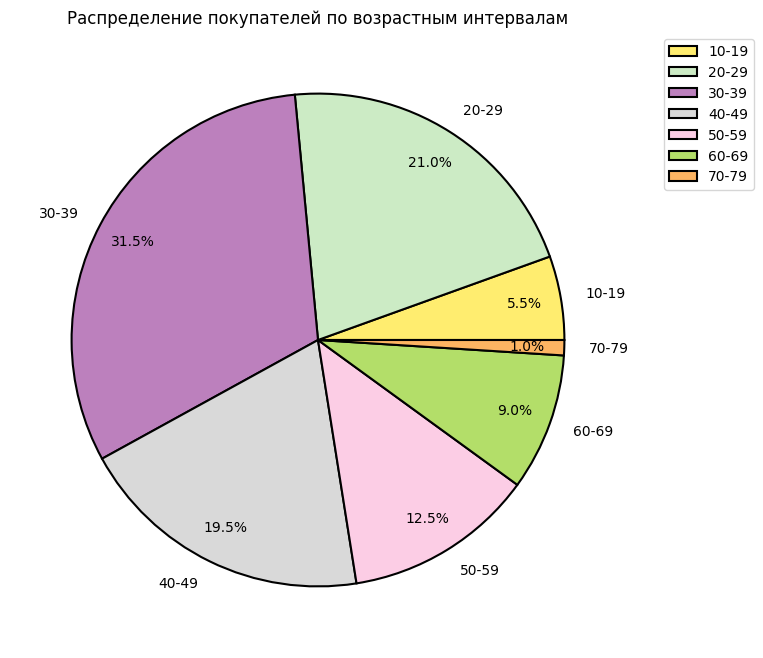

In [36]:
min_age = int(data['Age'].min())
max_age = int(data['Age'].max())

start_age = (min_age // 10) * 10
end_age = ((max_age // 10) + 1) * 10

age_bins = np.arange(start_age, end_age + 10, 10)

age_labels = []

for i in range(len(age_bins) - 1):
    age_labels.append(f'{age_bins[i]}-{age_bins[i + 1] - 1}')

age_groups = pd.cut(
    data['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_counts = age_groups.value_counts().sort_index()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    pctdistance=0.85,
    autopct='%1.1f%%', 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}, 
    colors=plt.cm.Set3_r.colors
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Распределение покупателей по возрастным интервалам')

plt.show()

#### Задание 7. Построить столбчатую диаграмму по распределению доходов (по интервалу 25 тысяч).

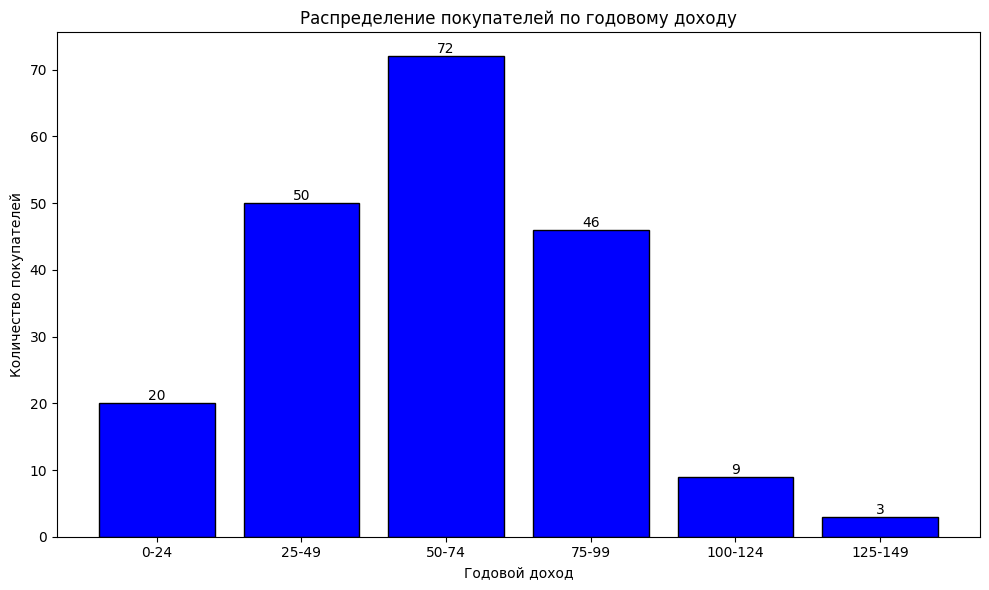

In [44]:
min_income = int(data['AnnualIncome'].min())
max_income = int(data['AnnualIncome'].max())

start_income = (min_income // 25) * 25
end_income = ((max_income // 25) + 1) * 25

income_bins = np.arange(start_income, end_income + 25, 25)

income_labels = []

for i in range(len(income_bins) - 1):
    income_labels.append(f'{income_bins[i]}-{income_bins[i + 1] - 1}')

income_groups = pd.cut(
    data['AnnualIncome'],
    bins=income_bins,
    labels=income_labels,
    right=False
)

income_counts = income_groups.value_counts().sort_index()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    income_counts.index,
    income_counts.values,
    color='blue',
    edgecolor='black'
)

plt.title('Распределение покупателей по годовому доходу')
plt.xlabel('Годовой доход')
plt.ylabel('Количество покупателей')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()